# 문제 유형 이해와 scikit-learn estimator 선택

이 노트북은 세 가지 데이터셋을 이용해 classification, regression, clustering 문제에서 어떤 estimator를 선택하고 어떻게 `fit`, `predict`, `score`, `fit_predict`를 쓰는지 확인합니다.  
각 데이터셋을 학습하기 전에 **데이터 로딩 → 피처 설명 → 데이터 미리보기 → 시각화**를 먼저 수행하도록 구성했습니다.

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.8.0


# Iris classification

## 데이터 로딩 및 피처 설명

**목표**: `iris` 데이터의 피처, target class, 샘플 수를 먼저 확인한 뒤 classification estimator를 선택합니다.

**피처 설명**

- `sepal length (cm)`: 꽃받침 길이
- `sepal width (cm)`: 꽃받침 너비
- `petal length (cm)`: 꽃잎 길이
- `petal width (cm)`: 꽃잎 너비
- `target`: 붓꽃 품종 번호. `0=setosa`, `1=versicolor`, `2=virginica`

이 데이터는 정답 label이 있는 **지도학습 classification** 문제입니다.


In [92]:
from sklearn.datasets import load_iris

In [93]:
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
iris_df["target_name"] = iris_df["target"].map(lambda x: iris.target_names[x])

In [94]:
X = iris.data.to_numpy()
y = iris.target.to_numpy()

In [95]:
print("full dataset:", X.shape, y.shape)
print("feature names:", iris.feature_names)
print("target names:", iris.target_names.tolist())
print("first labels:", y[:10].tolist(), np.unique(y))

full dataset: (150, 4) (150,)
feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names: ['setosa', 'versicolor', 'virginica']
first labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0] [0 1 2]


In [96]:
# 데이터 미리보기
display(iris_df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [97]:
# class별 샘플 수
iris_df["target_name"].value_counts()

target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [98]:
# 기초 통계
iris_df[iris.feature_names].describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


## 데이터 시각화

학습 전에 class 균형과 피처 분포를 확인합니다. 특히 petal 관련 피처는 품종 구분에 도움이 되는 패턴이 잘 보입니다.

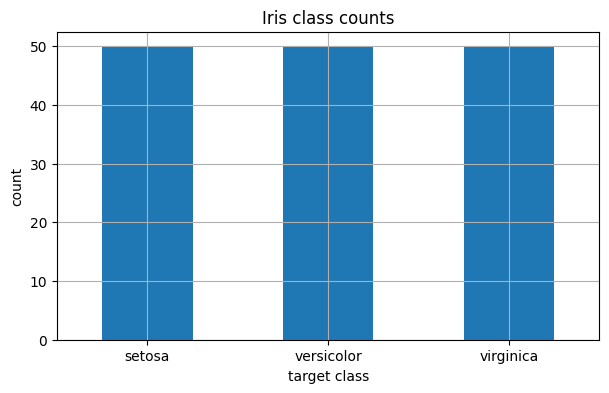

In [99]:
# class별 샘플 수
fig, ax = plt.subplots()
iris_df["target_name"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Iris class counts")
ax.set_xlabel("target class")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# petal length와 petal width의 관계
fig, ax = plt.subplots()
for name, group in iris_df.groupby("target_name"):
    ax.scatter(
        group["petal length (cm)"],
        group["petal width (cm)"],
        label=name,
        alpha=0.8,
    )
ax.set_title("Iris: petal length vs petal width")
ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.legend(title="species")
plt.show()

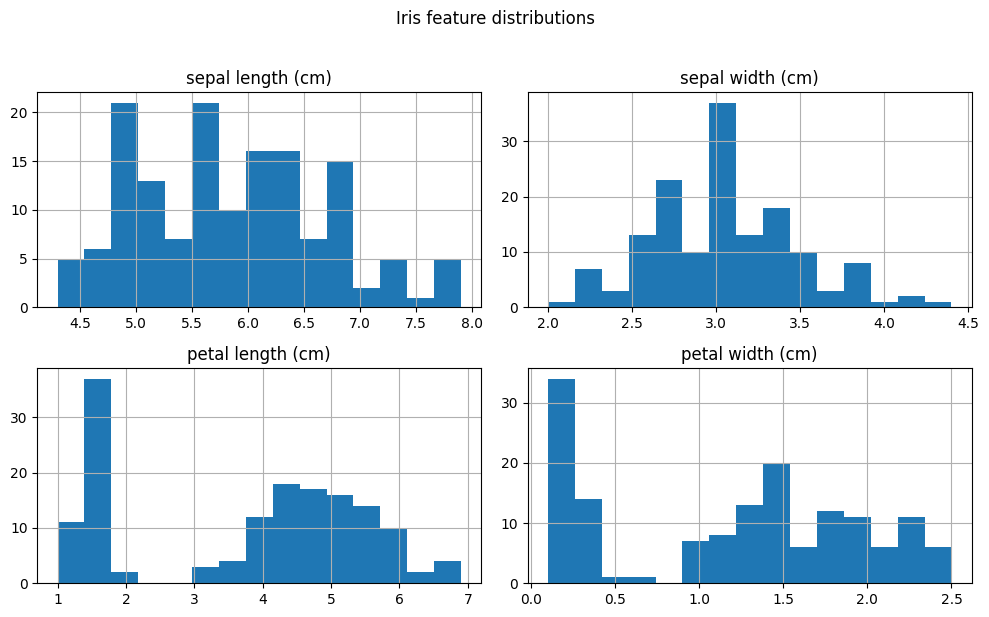

In [101]:
# 전체 피처 분포
iris_df[iris.feature_names].hist(bins=15, figsize=(10, 6))
plt.suptitle("Iris feature distributions", y=1.02)
plt.tight_layout()
plt.show()

## 학습 : train/test split 후 LinearSVC

**목표**: 같은 데이터로 학습과 채점을 동시에 하지 않도록 holdout set을 만들고, 작은 tabular classification의 첫 후보로 `LinearSVC`를 실행합니다.


In [104]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
print("train/test:", X_train.shape, X_test.shape)

train/test: (105, 4) (45, 4)


In [106]:
model = make_pipeline(
    StandardScaler(),
    LinearSVC(random_state=42)
)

In [107]:
# 학습
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


## predict와 score 비교

**목표**: `predict`는 label을 반환하고, `score`는 test set의 accuracy를 반환한다는 차이를 확인합니다.

In [108]:
pred = model.predict(X_test[:5])
score = model.score(X_test, y_test)

print("first predictions:", pred.tolist())
print("first label:", y_test[:5])
print("test accuracy:", round(score, 3))
print("prediction shape:", pred.shape)

first predictions: [2, 1, 1, 2, 2]
first label: [2 1 2 1 2]
test accuracy: 0.867
prediction shape: (5,)


# Diabetes regression

## Diabetes regression 데이터 로딩 및 피처 설명

**목표**: 숫자 `y`라도 class 번호가 아니라 연속값이면 regression estimator를 써야 함을 확인합니다.

**피처 설명**

- `age`: 나이
- `sex`: 성별 코드
- `bmi`: 체질량지수
- `bp`: 평균 혈압
- `s1` ~ `s6`: 혈청 검사 관련 수치
- `target`: 기준 시점으로부터 1년 뒤 질병 진행 정도를 나타내는 연속값

이 데이터는 target이 연속값인 **지도학습 regression** 문제입니다.


In [112]:
from sklearn.datasets import load_diabetes

# scaled=False를 사용하면 원래 단위에 가까운 값으로 데이터를 살펴볼 수 있습니다.
diabetes = load_diabetes(scaled=False, as_frame=True)
diabetes_df = diabetes.frame.copy()

X_reg = diabetes.data.to_numpy()
y_reg = diabetes.target.to_numpy()

print("diabetes:", X_reg.shape, y_reg.shape)
print("feature names:", diabetes.feature_names)
print("first targets:", [round(v, 1) for v in y_reg[:5]])

print()
print("[데이터 미리보기]")
display(diabetes_df.head())

print()
print("[기초 통계]")
display(diabetes_df.describe().T)


diabetes: (442, 10) (442,)
feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
first targets: [np.float64(151.0), np.float64(75.0), np.float64(141.0), np.float64(206.0), np.float64(135.0)]

[데이터 미리보기]


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0



[기초 통계]


,count,mean,std,min,25%,50%,75%,max
age,442.0,48.518100,13.109028,19.0000,38.2500,50.00000,59.0000,79.000
sex,442.0,1.468326,0.499561,1.0000,1.0000,1.00000,2.0000,2.000
bmi,442.0,26.375792,4.418122,18.0000,23.2000,25.70000,29.2750,42.200
bp,442.0,94.647014,13.831283,62.0000,84.0000,93.00000,105.0000,133.000
s1,442.0,189.140271,34.608052,97.0000,164.2500,186.00000,209.7500,301.000
s2,442.0,115.439140,30.413081,41.6000,96.0500,113.00000,134.5000,242.400
s3,442.0,49.788462,12.934202,22.0000,40.2500,48.00000,57.7500,99.000
s4,442.0,4.070249,1.290450,2.0000,3.0000,4.00000,5.0000,9.090
s5,442.0,4.641411,0.522391,3.2581,4.2767,4.62005,4.9972,6.107
s6,442.0,91.260181,11.496335,58.0000,83.2500,91.00000,98.0000,124.000


## Diabetes 데이터 시각화

학습 전에 target 분포와 주요 피처와 target의 관계를 확인합니다. 회귀 문제에서는 피처와 연속 target 사이의 상관관계를 먼저 보는 것이 유용합니다.

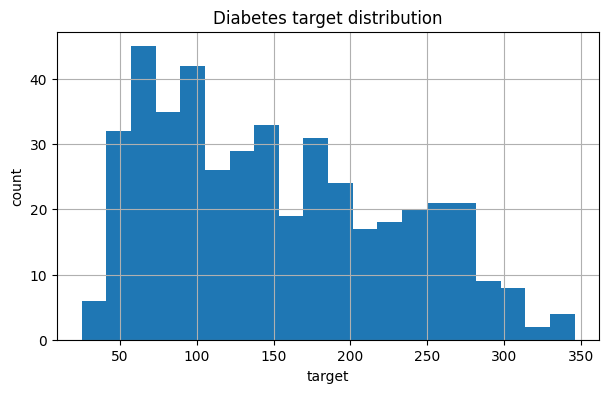

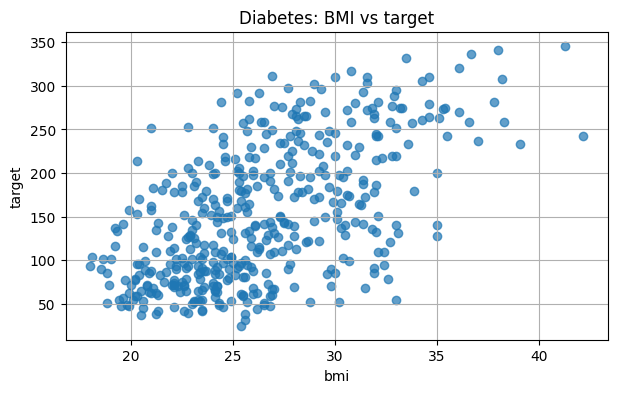

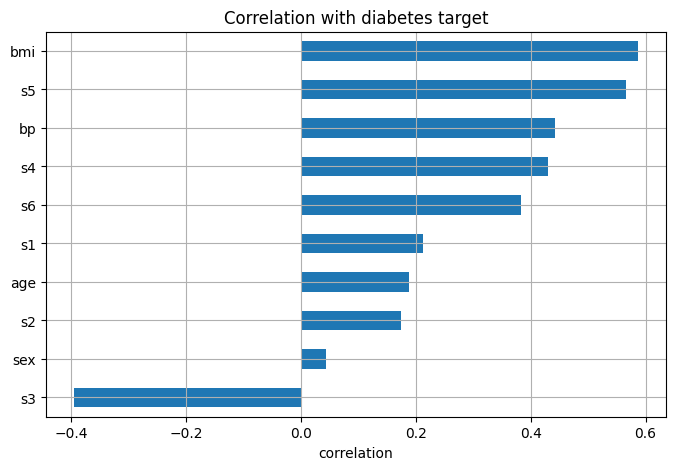

In [113]:
# target 분포
fig, ax = plt.subplots()
diabetes_df["target"].hist(bins=20, ax=ax)
ax.set_title("Diabetes target distribution")
ax.set_xlabel("target")
ax.set_ylabel("count")
plt.show()

# BMI와 target의 관계
fig, ax = plt.subplots()
ax.scatter(diabetes_df["bmi"], diabetes_df["target"], alpha=0.7)
ax.set_title("Diabetes: BMI vs target")
ax.set_xlabel("bmi")
ax.set_ylabel("target")
plt.show()

# 각 피처와 target의 상관계수
corr_with_target = diabetes_df.corr(numeric_only=True)["target"].drop("target").sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.plot(kind="barh", ax=ax)
ax.set_title("Correlation with diabetes target")
ax.set_xlabel("correlation")
plt.show()


## Ridge regression 학습 및 예측

**목표**: regression estimator인 `Ridge`를 학습하고, `score`가 R² 값을 반환한다는 점을 확인합니다.


In [118]:
from sklearn.linear_model import Ridge

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

reg = Ridge(alpha=1.0)
reg.fit(X_train_reg, y_train_reg)

print("r2:", round(reg.score(X_test_reg, y_test_reg), 3))
print("first predictions:", [round(v, 1) for v in reg.predict(X_test_reg[:3])])
print("first label:", y_test_reg[:3])

r2: 0.484
first predictions: [np.float64(137.7), np.float64(182.9), np.float64(130.2)]
first label: [219.  70. 202.]


**해석 + 다음 단계**: regression의 `predict`는 class label이 아니라 float 예측값을 반환합니다. 다음 단계에서는 `y` 없이 `fit_predict`를 쓰는 clustering 예제를 봅니다.


# blobs clustering

## `make_blobs` clustering 데이터 생성 및 피처 설명

**목표**: sample generator로 만든 cluster fixture에서 실제 학습에 들어가기 전에 synthetic 데이터의 구조를 먼저 확인합니다.

**피처 설명**

- `feature_0`: 2차원 평면의 첫 번째 좌표
- `feature_1`: 2차원 평면의 두 번째 좌표
- `true_cluster`: `make_blobs`가 검산용으로 만들어 준 정답 cluster 번호. 실제 KMeans 학습에는 사용하지 않습니다.

이 데이터는 clustering 구조를 관찰하기 위한 **비지도학습 예제**입니다. `true_cluster`는 평가용으로만 사용합니다.


In [120]:
from sklearn.datasets import make_blobs

X_blob, y_true_blob = make_blobs(
    n_samples=300, centers=3, cluster_std=0.60, random_state=0
)

blob_df = pd.DataFrame(X_blob, columns=["feature_0", "feature_1"])
blob_df["true_cluster"] = y_true_blob

print("synthetic:", X_blob.shape)
print("first true labels:", y_true_blob[:10].tolist())

print()
print("[데이터 미리보기]")
display(blob_df.head())

print()
print("[cluster별 샘플 수: 검산용 label]")
display(blob_df["true_cluster"].value_counts().sort_index().rename("count"))

print()
print("[기초 통계]")
display(blob_df[["feature_0", "feature_1"]].describe().T)


synthetic: (300, 2)
first true labels: [0, 1, 0, 2, 2, 2, 1, 0, 2, 2]

[데이터 미리보기]


,feature_0,feature_1,true_cluster
0,0.428577,4.973997,0
1,1.619909,0.067645,1
2,1.432893,4.376792,0
3,-1.578462,3.034458,2
4,-1.658629,2.267460,2



[cluster별 샘플 수: 검산용 label]


true_cluster
0    100
1    100
2    100
Name: count, dtype: int64


[기초 통계]


,count,mean,std,min,25%,50%,75%,max
feature_0,300.0,0.433244,1.618409,-2.948656,-1.091289,0.826162,1.697028,3.437618
feature_1,300.0,2.688586,1.566672,-0.765892,1.162992,2.909197,4.030363,5.474253


## Blob 데이터 시각화

KMeans 학습 전에 데이터가 2차원 공간에서 어떻게 모여 있는지 확인합니다. 여기서는 설명을 위해 generator가 제공한 `true_cluster`를 색 구분에 사용하지만, 실제 clustering 학습에는 이 값을 넣지 않습니다.


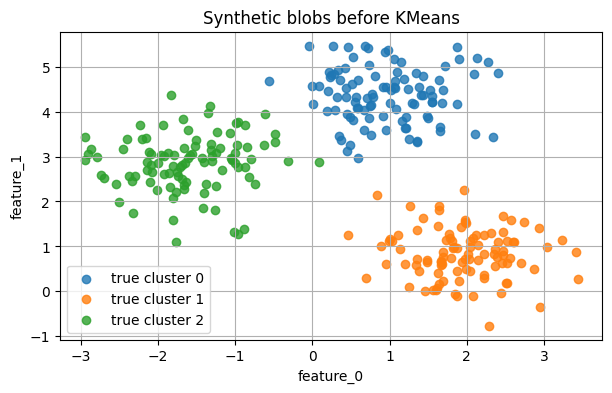

In [122]:
fig, ax = plt.subplots()
for cluster_id, group in blob_df.groupby("true_cluster"):
    ax.scatter(
        group["feature_0"],
        group["feature_1"],
        label=f"true cluster {cluster_id}",
        alpha=0.8,
    )
ax.set_title("Synthetic blobs before KMeans")
ax.set_xlabel("feature_0")
ax.set_ylabel("feature_1")
ax.legend()
plt.show()

## KMeans로 비지도 API 확인

**목표**: `KMeans.fit_predict`와 `KMeans.transform`의 출력을 확인합니다. `fit_predict`에는 `y_true_blob`를 넣지 않습니다.

In [132]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=3, n_init=10, random_state=0)
labels = km.fit_predict(X_blob)
distances = km.transform(X_blob[:5])

print("cluster centers:", km.cluster_centers_.round(2).tolist())
print("first predict labels:", labels[:10].tolist())
print("distance shape:", distances.shape)
print("ARI for teaching check:", round(adjusted_rand_score(y_true_blob, labels), 3))


cluster centers: [[-1.61, 2.86], [1.95, 0.83], [0.96, 4.37]]
first predict labels: [2, 1, 2, 0, 0, 0, 1, 2, 0, 0]
distance shape: (5, 3)
ARI for teaching check: 1.0


## KMeans 예측 cluster 시각화

아래 그래프는 KMeans가 예측한 cluster label로 같은 데이터를 다시 표시한 것입니다. 학습 전 데이터 구조와 학습 후 예측 label을 비교해 볼 수 있습니다.

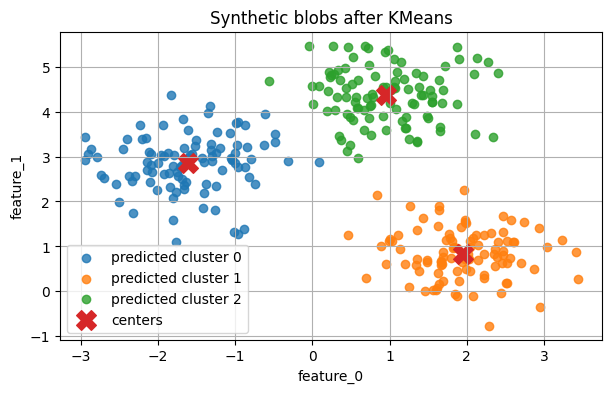

In [136]:
blob_df["kmeans_label"] = labels

fig, ax = plt.subplots()
for cluster_id, group in blob_df.groupby("kmeans_label"):
    ax.scatter(
        group["feature_0"],
        group["feature_1"],
        label=f"predicted cluster {cluster_id}",
        alpha=0.8,
    )

centers = pd.DataFrame(km.cluster_centers_, columns=["feature_0", "feature_1"])
ax.scatter(
    centers["feature_0"],
    centers["feature_1"],
    marker="X",
    s=200,
    label="centers",
)
ax.set_title("Synthetic blobs after KMeans")
ax.set_xlabel("feature_0")
ax.set_ylabel("feature_1")
ax.legend()
plt.show()


In [137]:
distances

array([[2.93634499, 4.41061994, 0.80032959],
       [4.26741239, 0.83567291, 4.35547804],
       [3.39882454, 3.57989471, 0.47665718],
       [0.17812771, 4.15936798, 2.86610044],
       [0.59350939, 3.88414456, 3.35675913]])

# 세 문제 유형을 한 표로 정리

**목표**: 방금 실행한 세 예제를 `y`의 의미, estimator, 주요 API 기준으로 정리합니다.

In [128]:
records = [
    {
        "data": "iris",
        "task": "classification",
        "target": "category label",
        "estimator": "LinearSVC pipeline",
        "main_api": "fit / predict / score",
    },
    {
        "data": "diabetes",
        "task": "regression",
        "target": "continuous quantity",
        "estimator": "Ridge",
        "main_api": "fit / predict / score",
    },
    {
        "data": "blobs",
        "task": "clustering",
        "target": "no target for fitting",
        "estimator": "KMeans",
        "main_api": "fit_predict / transform",
    },
]

summary_df = pd.DataFrame(records)
display(summary_df)

for row in records:
    print(f"{row['data']}: {row['task']}")
    print(f"  target: {row['target']}")
    print(f"  estimator: {row['estimator']}")
    print(f"  api: {row['main_api']}")


,data,task,target,estimator,main_api
0,iris,classification,category label,LinearSVC pipeline,fit / predict / score
1,diabetes,regression,continuous quantity,Ridge,fit / predict / score
2,blobs,clustering,no target for fitting,KMeans,fit_predict / transform


iris: classification
  target: category label
  estimator: LinearSVC pipeline
  api: fit / predict / score
diabetes: regression
  target: continuous quantity
  estimator: Ridge
  api: fit / predict / score
blobs: clustering
  target: no target for fitting
  estimator: KMeans
  api: fit_predict / transform
